# Solving TSP using Quantum Annealing (QPU) - Exact Solution

*Time Complexity : O(N^4)
<br>
The time complexity is dominated by the QUBO generator*
<br>
*Space Complexity : O(N^2)
<br>
Space complexity is determined by the QUBO matrix, which scales quadratically with the number of nodes.*
<br>
<br>
*Due to limited hardware access, the Direct QPU that we're currently using cann't solve Graphs wihh more than 6 nodes with 100% optimality. For largers graphs we will use Hybrid Solver*

In [1]:
import networkx as nx
import itertools
from collections import defaultdict
from dwave.system import DWaveSampler, EmbeddingComposite
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def QUBO_generator(G, lagrange=None, weight='weight', missing_edge_weight=None):
    """
    Generate a QUBO formulation for the Traveling Salesperson Problem (TSP) given a graph.

    This function converts a complete graph into a QUBO (Quadratic Unconstrained Binary Optimization)
    formulation suitable for solving the TSP. The QUBO formulation includes both the objective function 
    to minimize the total tour length and the constraints ensuring each city is visited exactly once.

    Parameters
    ----------
    G : NetworkX graph
        A complete graph where each edge has a weight attribute indicating the distance between nodes.

    lagrange : float, optional
        The Lagrange multiplier for weighting the constraints in the QUBO. If not provided, it is estimated
        based on the average tour length.

    weight : str, optional
        The name of the edge attribute used for weights. Default is 'weight'.

    missing_edge_weight : float, optional
        The weight assigned to edges not present in the graph. If None, it is set to the sum of all edge weights.

    Returns
    -------
    Q : dict
        A dictionary representing the QUBO, where keys are pairs of variable tuples and values are the QUBO coefficients.
    """
    N = G.number_of_nodes()

    # Estimate the Lagrange parameter if not provided
    if lagrange is None:
        if G.number_of_edges() > 0:
            lagrange = G.size(weight=weight) * G.number_of_nodes() / G.number_of_edges()
        else:
            lagrange = 2
    
    # Set default missing edge weight if not provided
    if missing_edge_weight is None:
        missing_edge_weight = G.size(weight=weight)

    # Ensure the graph has at least 3 nodes
    if N in (1, 2):
        raise ValueError("Graph must have at least 3 nodes or be empty")

    Q = defaultdict(float)

    # Constraint: Each city must appear exactly once in each position
    for node in G:
        for pos_1 in range(N):
            Q[((node, pos_1), (node, pos_1))] -= lagrange
            for pos_2 in range(pos_1 + 1, N):
                Q[((node, pos_1), (node, pos_2))] += 2.0 * lagrange

    # Constraint: Each position must be occupied by exactly one city
    for pos in range(N):
        for node_1 in G:
            Q[((node_1, pos), (node_1, pos))] -= lagrange
            for node_2 in set(G) - {node_1}:
                Q[((node_1, pos), (node_2, pos))] += lagrange

    # Objective function
    for u, v in itertools.combinations(G.nodes, 2):
        for pos in range(N):
            nextpos = (pos + 1) % N

            try:
                value = G[u][v][weight]
            except KeyError:
                value = missing_edge_weight

            Q[((u, pos), (v, nextpos))] += value

            try:
                value = G[v][u][weight]
            except KeyError:
                value = missing_edge_weight

            Q[((v, pos), (u, nextpos))] += value

    # Enforce that city 0 is at position 0
    for pos in range(1, N):
        Q[((0, pos), (0, pos))] += lagrange * 10  # Penalize other positions for city 0

    return Q

In [3]:
def extract_path(sample, N):
    """
    Extracts the path from a binary sample of the QUBO solution.

    Parameters
    ----------
    sample : dict
        A dictionary where keys are tuples representing the QUBO variables (node, position) and 
        values are binary values (0 or 1) indicating whether the variable is active in the solution.
    N : int
        The number of nodes in the graph, which corresponds to the number of positions in the path.

    Returns
    -------
    path : list
        A list of length N where each index represents a position in the tour and contains the node 
        visited at that position. If a position is filled with -1, it indicates an invalid or empty 
        slot in the path.
    """
    # Initialize the path with -1 to indicate unassigned positions
    path = [-1] * N
    
    # Iterate through the sample to find the nodes at each position
    for (node, pos), value in sample.items():
        if value == 1:
            # Assign the node to the correct position in the path
            path[pos] = node
            
    return path

In [4]:
def generate_random_graph(num_nodes, min_weight=1, max_weight=100):
    """
    Generate a complete graph with random edge weights.

    This function creates a complete graph with the specified number of nodes.
    Each edge in the graph is assigned a random weight between the given
    minimum and maximum weights, inclusive.

    Parameters
    ----------
    num_nodes : int
        The number of nodes in the complete graph.
    min_weight : int, optional (default=1)
        The minimum weight assigned to any edge.
    max_weight : int, optional (default=100)
        The maximum weight assigned to any edge.

    Returns
    -------
    networkx.Graph
        A complete graph with nodes and edges, where each edge has a random weight.
    """
    
    G = nx.complete_graph(num_nodes)
    
    # Assign random weights to each edge
    for (i, j) in G.edges:
        G[i][j]['weight'] = np.random.randint(min_weight, max_weight + 1)
    
    return G

In [5]:
def calculate_tour_length(path, G, weight='weight'):
    """
    Calculate the total length of a tour given a path and a graph.

    This function computes the sum of weights for the edges that form the tour.
    The tour is represented as a sequence of nodes, and the function calculates
    the total distance by summing the weights of the edges connecting each pair
    of consecutive nodes in the path.

    Parameters
    ----------
    path : list
        A list representing the order of nodes in the tour. The length of the list
        should be equal to the number of nodes in the graph.

    G : networkx.Graph
        The graph object that contains the edges and their weights.

    weight : str, optional (default='weight')
        The attribute name of the edge weight in the graph. This specifies which
        attribute of the edge to use as the weight.

    Returns
    -------
    float
        The total length of the tour. If any edge in the path does not exist in
        the graph (i.e., missing weight), the function returns `float('inf')` to
        indicate an invalid tour.

    """
    tour_length = 0
    N = len(path)

    for i in range(N):
        u = path[i]
        v = path[(i + 1) % N]  # modulo to wrap around to the start for the last edge

        try:
            tour_length += G[u][v][weight]
        except KeyError:
            return float('inf')  # Return infinite length if edge weight is missing

    return tour_length

In [6]:
def is_valid_tour(path, G):
    """
    Validate if the given path represents a valid tour in the graph.

    A valid tour must:
    1. Include all nodes in the graph exactly once.
    2. Not contain any duplicate nodes.

    Parameters
    ----------
    path : list
        A list of nodes representing the order in which nodes are visited.

    G : networkx.Graph
        The graph for which the tour is being validated.

    Returns
    -------
    bool
        True if the path is a valid tour (i.e., it includes every node exactly once),
        False otherwise.
    """
    return sorted(path) == list(G.nodes) and len(set(path)) == len(path)

In [7]:
def plot_graph_and_path(G, path):
    # Generate a consistent layout for the graph nodes
    pos = nx.spring_layout(G, seed=42)  # Setting a seed ensures the layout remains consistent across runs
    plt.figure(figsize=(8, 6))  # Create a figure with custom size

    # Draw the nodes of the graph
    nx.draw_networkx_nodes(
        G, pos, node_color='skyblue', node_size=800, edgecolors='k', linewidths=2
    )  # Nodes are displayed in sky blue with black borders and larger size

    # Draw all edges with a light gray color to differentiate from the TSP path
    nx.draw_networkx_edges(
        G, pos, edgelist=G.edges(), edge_color='gray', width=2, alpha=0.6
    )  # Light gray color and semi-transparent edges to indicate all connections

    # Highlight the optimal TSP path in red with thicker, solid edges
    tsp_edges = [(path[i], path[(i + 1) % len(path)]) for i in range(len(path))]
    nx.draw_networkx_edges(
        G, pos, edgelist=tsp_edges, edge_color='red', width=3.5, style='solid'
    )  # Thicker red edges show the specific TSP path

    # Add edge labels to show the weights of each edge
    edge_labels = nx.get_edge_attributes(G, 'weight')  # Retrieve the edge weights from the graph
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12, font_color='black')

    # Add labels for the graph nodes
    nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')  # Bold and larger node labels for clarity

    # Add a title and format the plot
    plt.title("Optimal TSP Path", size=16, fontweight='bold')  # Title to indicate the plot's purpose
    plt.axis('off')  # Turn off the axes for a cleaner look
    plt.tight_layout()  # Adjust layout to prevent overlapping elements

    # Display the plot
    plt.show()  # Show the graphical output


In [8]:
def visualize_graph(G):
    """
    Visualizes the graph with edge weights using NetworkX and Matplotlib.

    Parameters
    ----------
    G : networkx.Graph
        The graph object to be visualized.
    """
    # Generate a layout for the nodes
    pos = nx.spring_layout(G, seed=42)  # Using a seed for reproducible layout

    # Draw the nodes
    nx.draw_networkx_nodes(G, pos, node_size=700, node_color='lightblue', edgecolors='k', linewidths=2)

    # Draw the edges with weights
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.7, edge_color='gray')
    
    # Draw edge labels (weights)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

    # Draw the labels for nodes
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    # Title and formatting
    plt.title("Graph Visualization", size=16)
    plt.axis('off')  # Turn off the axes
    plt.tight_layout()  # Adjust layout to fit elements

    # Show the plot
    plt.show()

In [9]:
num_nodes = 5
G = generate_random_graph(num_nodes)

In [10]:
print("\nGenerated Graph:")
print("Edges and weights:", list(G.edges(data=True)))


Generated Graph:
Edges and weights: [(0, 1, {'weight': 61}), (0, 2, {'weight': 79}), (0, 3, {'weight': 16}), (0, 4, {'weight': 36}), (1, 2, {'weight': 74}), (1, 3, {'weight': 87}), (1, 4, {'weight': 63}), (2, 3, {'weight': 36}), (2, 4, {'weight': 61}), (3, 4, {'weight': 76})]


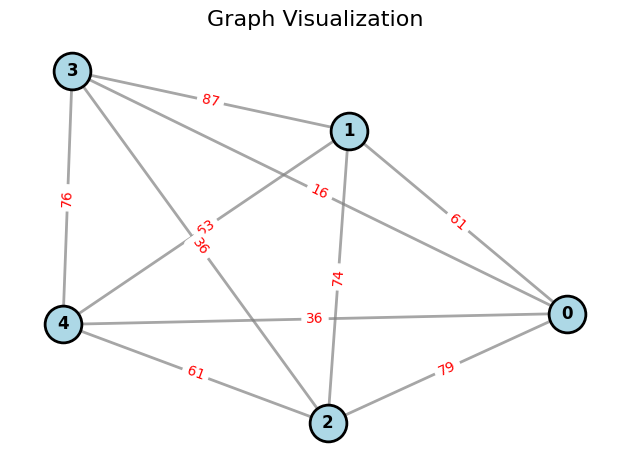

In [11]:
visualize_graph(G)

In [12]:
Q = QUBO_generator(G)

In [13]:
# Initialize the Quantum Annealing sampler for solving the QUBO problem
sampler = EmbeddingComposite(DWaveSampler())

In [14]:
# Perform the sampling using the QUBO formulation
response = sampler.sample_qubo(Q, num_reads=100)

In [15]:
# Extract the first (best) sample from the response
# The sample represents the variable assignments with the lowest energy
best_sample = response.first.sample

# Retrieve the energy associated with the best sample
# The energy is a measure of the objective function value for the sample
best_energy = response.first.energy

In [16]:
# Extract the sequence of cities (path) from the best sample solution obtained from the QUBO solver.
# The `best_sample` dictionary contains the binary values indicating which city occupies each position in the tour.
# `G.number_of_nodes()` provides the number of cities in the graph, which is used to correctly reconstruct the path.
path = extract_path(best_sample, G.number_of_nodes())

In [17]:
print(f"\nOptimal Solution (Simulated Annealing):")
print(f"Sample: {best_sample}, Energy: {best_energy}")


Optimal Solution (Simulated Annealing):
Sample: {(0, 0): np.int8(1), (0, 1): np.int8(0), (0, 2): np.int8(0), (0, 3): np.int8(0), (0, 4): np.int8(0), (1, 0): np.int8(0), (1, 1): np.int8(0), (1, 2): np.int8(1), (1, 3): np.int8(0), (1, 4): np.int8(0), (2, 0): np.int8(0), (2, 1): np.int8(0), (2, 2): np.int8(0), (2, 3): np.int8(1), (2, 4): np.int8(0), (3, 0): np.int8(0), (3, 1): np.int8(0), (3, 2): np.int8(0), (3, 3): np.int8(0), (3, 4): np.int8(1), (4, 0): np.int8(0), (4, 1): np.int8(1), (4, 2): np.int8(0), (4, 3): np.int8(0), (4, 4): np.int8(0)}, Energy: -2720.0


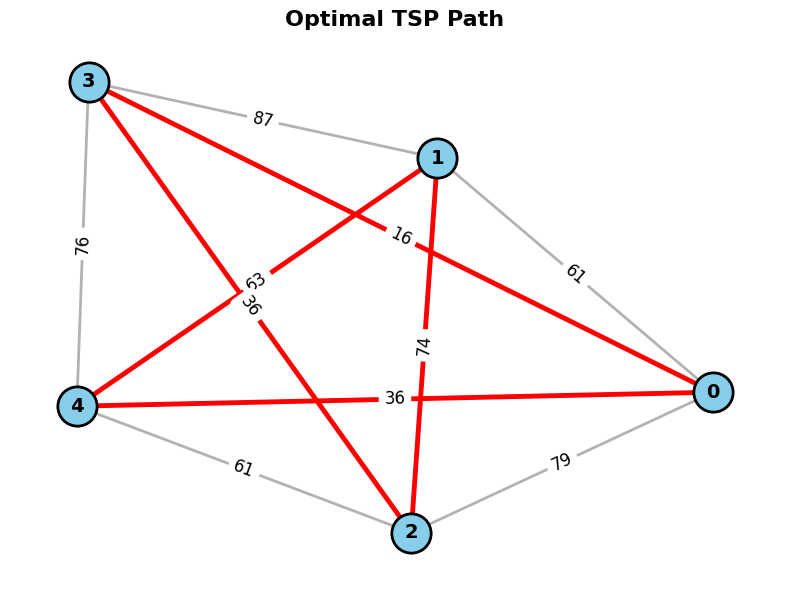

In [18]:
# Plot the graph and the TSP path
plot_graph_and_path(G, path)

In [19]:
# Check if the extracted path forms a valid tour
if is_valid_tour(path, G):
    # Calculate the length of the tour if the path is valid
    tour_length = calculate_tour_length(path, G)
    # Print the valid path and its length
    print(f"\nPath: {path} is valid.")
    print(f"Tour Length: {tour_length}")
else:
    # Inform if the path does not form a valid tour
    print(f"\nPath: {path} is not valid.")


Path: [0, 4, 1, 2, 3] is valid.
Tour Length: 225


In [20]:
timing_info = response.info['timing']

print(timing_info)

{'qpu_sampling_time': 8376.0, 'qpu_anneal_time_per_sample': 20.0, 'qpu_readout_time_per_sample': 43.18, 'qpu_access_time': 24141.56, 'qpu_access_overhead_time': 1227.44, 'qpu_programming_time': 15765.56, 'qpu_delay_time_per_sample': 20.58, 'total_post_processing_time': 16.0, 'post_processing_overhead_time': 16.0}


In [21]:
total_time = sum([value for key, value in timing_info.items()]) / (10 ** 6)

print(f"Total QPU run-time {total_time:.5f} s")


Total QPU run-time 0.04963 s


# Checking Optimality 

In [22]:
def tour_length(path, G):
    length = 0
    N = len(path)
    
    for i in range(N):
        u = path[i]
        v = path[(i + 1) % N]  # Wrap around to the start for the last edge
        
        if G.has_edge(u, v):
            length += G[u][v]['weight']
        else:
            return float('inf')  # Return infinite length if edge weight is missing
    
    return length


In [23]:

def find_optimal_tsp_path(G):
    nodes = list(G.nodes)
    permutations = itertools.permutations(nodes)
    
    min_length = float('inf')
    optimal_paths = []

    for perm in permutations:
        length = tour_length(perm, G)
        if length < min_length:
            min_length = length
            optimal_paths = [perm]
        elif length == min_length:
            optimal_paths.append(perm)

    return optimal_paths, min_length


In [24]:

def calculate_optimality_percentage(quantum_length, classical_length):
    if classical_length == float('inf'):
        return 0
    return (classical_length / quantum_length) * 100


In [25]:

quantum_length = calculate_tour_length(path, G)

optimal_path, classical_length = find_optimal_tsp_path(G)


In [26]:

# Compute the optimality percentage
optimality_percentage = calculate_optimality_percentage(quantum_length, classical_length)

print(f"Optimality: {optimality_percentage:.2f}%")

Optimality: 100.00%
